# Classification Metrics with Scikit-Learn


Evaluating the performance of classification models is crucial for understanding their effectiveness and guiding improvements. This notebook provides a guide on how to compute various classification metrics using the `scikit-learn` library. We will cover the *confusion matrix* and related performance metrics such as *accuracy*, *recall*, *precision*, and *F1 score*. These are common metrics for gauging the performance of models in both **binary** and **multiclass** classification scenarios.

*Dataset Preparation*. We will use `scikit-learn` to generate synthetic datasets, which serve as a controlled environment to illustrate how these metrics are calculated.

*Model Training*. For the purposes of this demonstration, we will employ a basic *Logistic Regression* classifier. As you know, Logistic Regression is a foundational algorithm suitable for binary classification problems and, with minor adjustments, can be extended to handle multiclass classification as well.

*Metric Calculation*. Once we have trained our model, we will use `scikit-learn`'s built-in functions to compute the classification metrics. Not only is `scikit-learn` a robust tool for various machine learning tasks, but it also provides compatibility with other frameworks, including `PyTorch`. This compatibility is particularly useful when working with deep learning models, where you might train a classifier using PyTorch and then evaluate it using the metric functions available in `scikit-learn`.


## Setup

First, we need to import the necessary libraries and create fake datasets for our examples.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, classification_report
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## Binary Classification

### Confusion Matrix

A confusion matrix is a table used to describe the performance of a classification model on a set data for which the true values are known. It presents the comparison between the actual and predicted values. In binary classification, it has two rows and two columns, representing the two classes (positive and negative). The matrix is organized as follows:

- **True Positives (TP)**: The number of positive instances correctly classified as positive.
- **False Positives (FP)**: The number of negative instances incorrectly classified as positive.
- **True Negatives (TN)**: The number of negative instances correctly classified as negative.
- **False Negatives (FN)**: The number of positive instances incorrectly classified as negative.

![Illustration of Confusion Matrix](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRKZKJFCLpRBJC2Hrg6vor8J5S2-5W5y9nY0hm4TYJzwoJiG6uC2HEZiAEqBjW5Q7Vw-0k&usqp=CAU)

### Classification Metrics

If we identify with *P* and *N* the total number of positive and negative examples in the entire dataset, we can define the main performance metrics as below:

<table class="wikitable" align="center" style="border:none; background:transparent; text-align:center;">  
  <caption style="caption-side: top; text-align: center; font-weight: bold;">Performance Metrics for Binary Classification</caption>
  <tr>
    <td>Accuracy</td>
    <td colspan="2">= (TP + TN) / (P + N)</td>
  </tr>
  <tr>
    <td>Recall (or Sensitivity)</td>
    <td colspan="2">= TP / (TP + FN)</td>
  </tr>
  <tr>
    <td>Precision (or Positive Predictive Value)</td>
    <td colspan="2">= TP / (TP + FP)</td>
  </tr>
  <tr>
    <td>F1 Score</td>
    <td colspan="2">= 2 * (Precision * Recall) / (Precision + Recall)</td>
  </tr>
</table>



**Accuracy** measures the proportion of total correct predictions (both positive and negative) out of all predictions. While accuracy is a useful metric, it may not be sufficient in cases where the class distribution is imbalanced.

**Recall**, also known as sensitivity, measures the proportion of actual positives that are correctly identified. It is particularly important when the cost of false negatives is high.

**Precision** assesses the proportion of positive identifications that were actually correct. It is crucial in scenarios where false positives are a greater concern than false negatives.

The **F1 Score** is the harmonic mean of precision and recall, providing a balance between the two. It is especially useful when you need a single metric to compare models that may have different precision and recall values.

Each of these metrics offers unique insights into the performance of a binary classification model, helping to understand its strengths and weaknesses in different aspects of prediction. More metrics exist, such as those listed [here](https://en.wikipedia.org/wiki/Confusion_matrix).




### Code Implementation

In [ ]:
# Generate a dataset
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=42)

# Add Gaussian noise to the dataset
noise = np.random.normal(0, 1, X.shape)
X = X + noise

# Split the noisy dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# fit logistic regression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

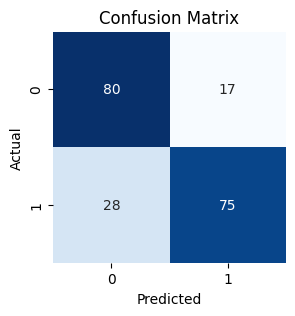

Confusion Matrix:
 [[80 17]
 [28 75]]
Accuracy: 0.7750
Recall: 0.7282
Precision: 0.8152
F1 Score: 0.7692


In [ ]:
# Making predictions
y_pred = model.predict(X_test)

# Computing metrics
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Displaying the confusion matrix with a heatmap
plt.figure(figsize=(3, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Results
print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")

## Multiclass classification

### Confusion Matrix for Multi-Class Classification



<table>
  <tr>
    <th><b></b></th>
    <th colspan="5" >Predicted</th>
  </tr>
  <tr>
    <th><b>Actual</b></th>
    <th>Forest</th>
    <th>Urban</th>
    <th>Water</th>
    <th>Agriculture</th>
    <th>Mountain</th>
  </tr>
  <tr>
    <td><b>Forest</b></td>
    <td>xx</td> <!-- Forest correctly predicted as Forest -->
    <td>xx</td> <!-- Forest incorrectly predicted as Urban -->
    <td>xx</td> <!-- Forest incorrectly predicted as Water -->
    <td>xx</td> <!-- Forest incorrectly predicted as Agriculture -->
    <td>xx</td> <!-- Forest incorrectly predicted as Mountain -->
  </tr>
  <tr>
    <td><b>Urban</b></td>
    <td>xx</td> <!-- Urban incorrectly predicted as Forest -->
    <td>xx</td> <!-- Urban correctly predicted as Urban -->
    <td>xx</td> <!-- Urban incorrectly predicted as Water -->
    <td>xx</td> <!-- Urban incorrectly predicted as Agriculture -->
    <td>xx</td> <!-- Urban incorrectly predicted as Mountain -->
  </tr>
  <tr>
    <td><b>Water</b></td>
    <td>xx</td> <!-- Water incorrectly predicted as Forest -->
    <td>xx</td> <!-- Water incorrectly predicted as Urban -->
    <td>xx</td> <!-- Water correctly predicted as Water -->
    <td>xx</td> <!-- Water incorrectly predicted as Agriculture -->
    <td>xx</td> <!-- Water incorrectly predicted as Mountain -->
  </tr>
  <tr>
    <td><b>Agriculture</b></td>
    <td>xx</td> <!-- Agriculture incorrectly predicted as Forest -->
    <td>xx</td> <!-- Agriculture incorrectly predicted as Urban -->
    <td>xx</td> <!-- Agriculture incorrectly predicted as Water -->
    <td>xx</td> <!-- Agriculture correctly predicted as Agriculture -->
    <td>xx</td> <!-- Agriculture incorrectly predicted as Mountain -->
  </tr>
  <tr>
    <td><b>Mountain</b></td>
    <td>xx</td> <!-- Mountain incorrectly predicted as Forest -->
    <td>xx</td> <!-- Mountain incorrectly predicted as Urban -->
    <td>xx</td> <!-- Mountain incorrectly predicted as Water -->
    <td>xx</td> <!-- Mountain incorrectly predicted as Agriculture -->
    <td>xx</td> <!-- Mountain correctly predicted as Mountain -->
  </tr>
</table>



A confusion matrix for multi-class classification is an extension of the binary classification matrix, but instead of two classes, it includes all the classes being predicted. The matrix compares the actual target values with those predicted by the model, providing a comprehensive view of the performance across all classes. The confusion matrix for a multi-class classification problem has the same basic structure as the binary case but is expanded to include each class as both a row and a column.


### Performance Metrics for Multi-Class Classification


**Accuracy** is still the proportion of correctly predicted observations to the total observations, but in multi-class problems, it is often more insightful to look at class-specific metrics due to the potential for class imbalance.

In multi-class classification, the definitions of **recall**, **precision**, and **F1 score** remain the same conceptually, but their calculations can consider all classes simultaneously or one class at a time.

**Recall** in the multi-class setting can be calculated for each class individually or averaged across classes. The **macro-average** will compute the metric independently for each class and then take the average, treating all classes equally. On the other hand, the **weighted-average** will account for class imbalance by weighting the recall scores of each class by their occurrences in the dataset.

**Precision** follows the same logic as recall, with macro and weighted averages providing different perspectives based on whether we wish to treat all classes equally or account for class frequency.

Accordingly, **F1 scores** for macro and weighted averaging are computed from the respective precision and recall metrics calculated using the same averaging method.

In `scikit-learn`, these metrics can be obtained using the `classification_report` function, which provides a breakdown of each class's precision, recall, and F1 score, or by using the `precision_score`, `recall_score`, and `f1_score` functions with the appropriate averaging method specified.

When selecting an averaging method for evaluating multi-class classification models using metrics like precision, recall, and F1 score, the choice depends on the specific aspects of the dataset and what you aim to emphasize in your model evaluation:

* Macro-Averaging. Choose this method when you want to treat each class equally, irrespective of their frequency in the dataset. Macro-averaging is ideal when you are equally interested in the performance across all classes and want to avoid biasing the metric towards more frequent classes.

* Weighted-Averaging: Opt for weighted averaging when your dataset exhibits class imbalance and you want to take into account the frequency of each class. This method weights the performance of each class by its representation in the dataset, making it suitable for scenarios where some classes are more prevalent or more important than others.

### Code Implementation

In [ ]:
# Generate a dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=3, weights=[0.5,0.4,0.1], random_state=42, n_informative=5)

# Add Gaussian noise to the dataset
noise = np.random.normal(0, 2, X.shape)
X = X + noise

# Split the noisy dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

              precision    recall  f1-score   support

           0       0.53      0.69      0.60        88
           1       0.56      0.55      0.56        85
           2       0.00      0.00      0.00        27

    accuracy                           0.54       200
   macro avg       0.36      0.42      0.39       200
weighted avg       0.47      0.54      0.50       200



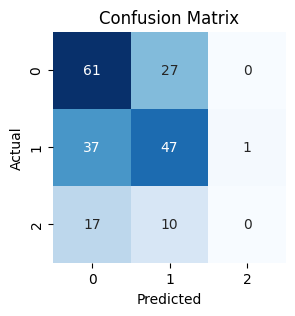

Confusion Matrix:
 [[61 27  0]
 [37 47  1]
 [17 10  0]]
Accuracy: 0.5400
Recall: 0.4154
Precision: 0.3633
F1 Score: 0.3857


In [ ]:
# Making predictions
y_pred = model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred))

# Computing metrics
conf_matrix = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# Displaying the confusion matrix with a heatmap
plt.figure(figsize=(3, 3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Displaying the results
print("Confusion Matrix:\n", conf_matrix)
print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
